# 5 L Tank Myristoylation -- Forward Predictive Simulation (Run 1 / Run 2, Non-Optimized)

This notebook runs **two independent, purely predictive (forward, non-optimized) simulations** of the
insulin desB30 -> Detemir myristoylation reaction in the 5 L reactor, for two real batch datasets
("Run 1", "Run 2") whose process conditions are already fully specified below. It is diagnostic, not
prescriptive: nothing here is fit, swept, or tuned -- every parameter is either taken directly from the
task specification or **retained unchanged** from the validated template `myr_mechanistic_model_5L_optimized_FIXED.ipynb`.

**What is retained unchanged from the template (per the "zero optimization" requirement):**
- The DS-Pool pooled reaction network and rate laws (Section 3 below) -- same 6 lumped rate constants `k`,
  same fractional reaction orders `n` (NHS-Myr) and `m` (acylation substrate), loaded from the same fitted
  bundle (`02jul2026_ds_pool_refined_results.pkl`) the template uses.
- The flow number **Nq = 0.020**, anchored in `kinetika3b.ipynb`'s real Tris/HCl titration fit for this same
  IKA EASYSYN5000 vessel -- carried over as-is, not re-derived.
- The dual-compartment (2-zone) mass-transport architecture: Zone 1 ("feed zone", impeller height -> liquid
  surface, grows as volume is added) and Zone Bulk (fixed zone below the impeller), coupled by an
  impeller-driven circulation flow `Q`.
- The template's numerical safeguard for the near-zero-order NHS-Myr kinetics (n &asymp; 0.12): a smooth
  concentration floor inside every fractional-power rate term. Section 6 below adapts this into a
  **reaction-rate gate** (rather than the template's terminal stopping event) because these two runs need to
  keep integrating for a fixed real-world duration, not stop as soon as the model thinks NHS-Myr is used up --
  see the callout in Section 6 for why.

**What is new / different for these two runs (per the task's Observed Conditions, with one correction applied):**
- **Impeller speed = 450 rpm** (vs. the template's validated 160 rpm ceiling) and **impeller height = 5.9 cm**
  from the tank bottom (vs. the template's 8.0 cm). Tank diameter (20.5 cm) and impeller diameter (7.5 cm) are
  the same physical hardware, so only these two geometry/speed inputs change; Section 5 recomputes the
  dual-compartment volumes and circulation flow `Q` from them, and reports what that does to the vortex-safety
  and turbulence checks the template also performs.
- **NHS-Myristate stock = 18 mg/mL** and **Glycine stock = 0.07507 mg/mL** (vs. the template's 0.482 mg/mL and
  2.0 g/mL respectively) -- both far more dilute/concentrated than the template's values in different directions;
  used exactly as given.
- **Pump flow rate = 440 mL/min** for both incoming streams (NHS-Myr and Glycine), on the same physical pump,
  consistent with the template's "same pump for both additions" convention. Feed durations are **calculated
  programmatically** as `T_feed = Volume / 440 mL/min` for each stream, in Section 5 -- not assumed or tuned.
- **Corrected process timeline:** NHS-Myristate is fed into the desB30-charged reactor first; the reaction is
  then **held for 90 minutes** (measured from the start of the NHS-Myr feed) before Glycine is fed in on the
  same pump. This 90-minute hold was missing from the original task specification and is now applied to both
  runs exactly as reported.
- **Run-specific charge**: each run starts from its own already-prepared total reaction volume and initial
  desB30 concentration (given directly, so no ACN/buffer premix stage is needed here -- unlike the template,
  which built its desB30 charge from a 50/50 ACN/buffer split).

**On temperature and pH:** both runs are documented as running at 25 &plusmn; 0.1 &deg;C and pH 10.30 &plusmn; 0.05.
The template's kinetic model has **no explicit temperature or pH term** -- `k`, `n`, `m` are empirical fits
already characterized under specific experimental conditions. These process controls are recorded here as the
conditions under which the (retained, unmodified) kinetics are assumed to remain valid; they are not separate
mechanistic inputs to the ODE, and this notebook does not invent an Arrhenius or pH-dependence term that the
template itself does not have.

**Zero optimization policy:** there is no peak-detection, no sweep, no root-finding for a target endpoint
anywhere below (unlike the template's Sections 8 and 13, which are optimization passes and are intentionally
*not* reproduced here). Every run below simply integrates the given feed schedule forward in time and reports
what the model predicts.

In [5]:
# --- TOP CELL: RUN THIS ONCE ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import dill
import os
# -------------------------------

## 1. Shared bioprocess settings (both runs) and per-run datasets

All values below are taken directly from the task's Observed Conditions. `V_total_mL` and `desb30_mg_mL` are
each run's own charge (already-mixed reaction volume, no ACN/buffer premix modeled here). `V_nhs_mL` and
`V_gly_mL` are the volumes of NHS-Myristate stock and Glycine stock actually pumped into that volume.

In [6]:
MW_desb30   = 5706.0    # g/mol -- unchanged from template
MW_nhs_myr  = 325.44    # g/mol -- unchanged from template
MW_glycine  = 75.07     # g/mol -- unchanged from template

# --- Shared hardware / process settings ---
D_TANK_M      = 0.205   # m -- same 5 L IKA EASYSYN5000 vessel as the template
D_IMPELLER_M  = 0.075   # m -- same impeller hardware as the template
H_IMPELLER_M  = 0.059   # m -- 5.9 cm from tank bottom (NEW for this study; template used 8.0 cm)
N_RPM         = 450.0   # rpm (NEW for this study; template's validated ceiling was 160 rpm)
NQ            = 0.020   # flow number -- RETAINED UNCHANGED from kinetika3b.ipynb / the template

PUMP_RATE_ML_MIN  = 440.0   # mL/min -- shared pump, both incoming streams
NHS_STOCK_MG_ML   = 18.0        # mg/mL
GLY_STOCK_MG_ML   = 0.07507     # mg/mL (= 0.00007507 g/mL, as given)
V_REACTOR_MAX_ML  = 5000.0      # 5 L reactor ceiling (diagnostic check only, not optimized against)

# --- Per-run datasets ---
RUNS = {
    'Run 1': dict(V_total_mL=4178.7, desb30_mg_mL=2.125, V_nhs_mL=53.7, V_gly_mL=2.97),
    'Run 2': dict(V_total_mL=3869.0, desb30_mg_mL=2.211, V_nhs_mL=49.7, V_gly_mL=2.75),
}

for name, r in RUNS.items():
    print(f"{name}: V_total={r['V_total_mL']:.1f} mL, desB30={r['desb30_mg_mL']:.3f} mg/mL, "
          f"V_NHS-Myr={r['V_nhs_mL']:.1f} mL, V_Glycine={r['V_gly_mL']:.2f} mL")

Run 1: V_total=4178.7 mL, desB30=2.125 mg/mL, V_NHS-Myr=53.7 mL, V_Glycine=2.97 mL
Run 2: V_total=3869.0 mL, desB30=2.211 mg/mL, V_NHS-Myr=49.7 mL, V_Glycine=2.75 mL


## 2. Kinetics (DS-Pool refined fit) -- retained exactly as in the template
Same loader, same pickle bundle, same fallback constants as `myr_mechanistic_model_5L_optimized_FIXED.ipynb`.
`k`, `order_n`, `order_m` are not touched anywhere else in this notebook.

In [7]:
SPECIES = ['nhs_myr', 'desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3', 'glycine', 'gly_myr']
IDX = {name: i for i, name in enumerate(SPECIES)}
N_SPECIES = len(SPECIES)
N_COMPARTMENTS = 2  # Zone 1 (feed zone) + Zone Bulk -- same dual-compartment architecture as the template
REACTIVE_SPECIES = SPECIES

def load_kinetics(path='02jul2026_ds_pool_refined_results.pkl'):
    try:
        with open(path, 'rb') as f:
            bundle = dill.load(f)
        x = bundle['res_final'].x
        k = list(np.exp(x[:6]))
        n, m = float(x[6]), float(x[7])
        print(f"SUCCESS: Loaded DS-Pool refined fit (R^2={bundle.get('r2'):.4f}, RMSE={bundle.get('rmse'):.4f})")
        print(f'k = {k}')
        print(f'n (NHS-Myr order) = {n:.4f}, m (substrate order) = {m:.4f}')
    except Exception as e:
        print(f'WARNING: Using fallback parameters ({e}).')
        k = [4824.6912685716925, 1134.9009076406996, 177.1701312057297,
             13710.007107598605, 2114.9020833218583, 0.12584014547014327]
        n, m = 0.11873756023404723, 1.8915245993718806
    return k, n, m

k, order_n, order_m = load_kinetics()
k_quench = k[1]  # desb30 -> other_DS1 proxy (A1-type N-terminal-glycine acylation) -- same as template

SUCCESS: Loaded DS-Pool refined fit (R^2=0.7739, RMSE=0.1140)
k = [4824.6912685716925, 1134.9009076406996, 177.1701312057297, 13710.007107598605, 2114.9020833218583, 0.12584014547014327]
n (NHS-Myr order) = 0.1187, m (substrate order) = 1.8915


## 3. Reaction network -- retained exactly as in the template
Same smooth concentration floor, same pooled 5-reaction network + hydrolysis + glycine quench, same rate laws.
No parameter here is altered for the new operating conditions.

In [8]:
EPS_M = 1e-9  # 1 nM smoothing floor -- same rationale as the template (n=0.12 makes the rate law
              # nearly singular as NHS-Myr -> 0; see Section 6 for why a *terminal event* is also required
              # in addition to this floor)
def smooth_floor(c):
    return 0.5*(c + np.sqrt(c*c + EPS_M*EPS_M))

def calc_rate_mM_s(k_per_min, c_nhs_mM, c_sub_mM):
    c_nhs_M = smooth_floor(c_nhs_mM/1000.0)
    c_sub_M = smooth_floor(c_sub_mM/1000.0)
    return k_per_min * (c_nhs_M**order_n) * (c_sub_M**order_m) * (1000.0/60.0)

def calc_hydro_rate_mM_s(k_per_min, c_nhs_mM):
    c_nhs_M = smooth_floor(c_nhs_mM/1000.0)
    return k_per_min * c_nhs_M * (1000.0/60.0)

def reaction_derivs_mM_s(C, k, k_quench):
    '''C: dict of one compartment's concentrations (mM). Pooled 5-reaction network + hydrolysis + quench.'''
    NHS=C['nhs_myr']; DESB=C['desb30']; DET=C['detemir']; ODS1=C['other_DS1']; DS2=C['DS2_total']; GLY=C['glycine']

    r1 = calc_rate_mM_s(k[0], NHS, DESB)   # desb30 -> detemir (B29)
    r2 = calc_rate_mM_s(k[1], NHS, DESB)   # desb30 -> other_DS1 (A1+B1)
    r3 = calc_rate_mM_s(k[2], NHS, DET)    # detemir -> DS2_total
    r4 = calc_rate_mM_s(k[3], NHS, ODS1)   # other_DS1 -> DS2_total
    r5 = calc_rate_mM_s(k[4], NHS, DS2)    # DS2_total -> DS3
    r_hydro  = calc_hydro_rate_mM_s(k[5], NHS)     # NHS -> dead (hydrolysis)
    r_quench = calc_rate_mM_s(k_quench, NHS, GLY)  # NHS + glycine -> gly_myr

    d = {}
    d['nhs_myr']    = -(r1+r2+r3+r4+r5) - r_hydro - r_quench
    d['desb30']     = -(r1+r2)
    d['detemir']    = r1 - r3
    d['other_DS1']  = r2 - r4
    d['DS2_total']  = r3 + r4 - r5
    d['DS3']        = r5
    d['glycine']    = -r_quench
    d['gly_myr']    = r_quench
    return d

## 4. Hydrodynamics -- same Nq-based framework, scaled to 5.9 cm impeller height and 450 rpm
`calc_compartments` is the template's function, generalized to take impeller height and speed as arguments
(the template hardcoded 0.08 m / 160 rpm; here both are supplied explicitly instead). The functional form --
Zone Bulk volume fixed by geometry below the impeller, Zone 1 growing with added volume, `Q` from the flow
number -- is unchanged.

**Turbulence check (does the constant-Nq assumption still hold at 450 rpm?):** the flow number is only safely
treated as a geometry-only constant once the impeller Reynolds number is solidly in the turbulent regime
(Re = &rho;ND&sup2;/&mu;). At 160 rpm the template's own system already sits at Re &asymp; 1.5&times;10&#8308;;
at 450 rpm it is checked below and is, if anything, even more comfortably turbulent -- so reusing Nq=0.044
unchanged is well justified here, more so than at the template's lower speed.

**Vortex-safety check (Froude number):** the template fixed 160 rpm specifically as the *highest* speed
keeping the unbaffled impeller Froude number under the vortex-onset threshold Fr_crit=0.15. 450 rpm is a task-given
condition, not something optimized here, so it is **not** adjusted -- but the same check is run and reported
so the vortex-risk status of this operating point is not silently skipped.

In [9]:
AREA_TANK_M2 = np.pi * (D_TANK_M / 2.0) ** 2

def calc_compartments(V_current_L, h_impeller_m=H_IMPELLER_M, N_rpm=N_RPM):
    '''Dual-compartment hydrodynamics -- same framework as myr_mechanistic_model_5L_optimized_FIXED.ipynb,
    generalized to take impeller height and rpm as arguments (this study: 5.9 cm, 450 rpm) instead of the
    template's fixed 8.0 cm / 160 rpm. Nq=0.044 is retained unchanged.
    Zone 1 (index 0) = feed zone: impeller height -> liquid surface, grows as volume is added.
    Zone Bulk (index 1) = fixed zone below the impeller.
    '''
    N_rps = N_rpm / 60.0
    Q_L_s = NQ * N_rps * D_IMPELLER_M ** 3 * 1000.0

    V_bulk_L = AREA_TANK_M2 * h_impeller_m * 1000.0
    V1_L = max(0.01, V_current_L - V_bulk_L)

    return V1_L, V_bulk_L, Q_L_s

def transport_moles(row_moles, V1, V2, Q):
    N1, N2 = row_moles
    C1, C2 = N1/V1, N2/V2
    f12 = Q*(C1-C2)
    return np.array([-f12, f12])

# --- Hydrodynamic checks at the task-specified 450 rpm / 5.9 cm operating point ---
Fr_crit_unbaffled = 0.15
Fr_i_450 = (N_RPM / 60.0) ** 2 * D_IMPELLER_M / 9.81

rho_water, mu_water = 1000.0, 0.001  # kg/m^3, Pa.s
Re_450 = rho_water * (N_RPM/60.0) * D_IMPELLER_M**2 / mu_water

_, V_bulk_check, Q_check_L_s = calc_compartments(4.0)  # 4 L probe volume, just to report Q and V_bulk
Q_check_L_min = Q_check_L_s * 60.0

print(f"Impeller Froude number at {N_RPM:.0f} rpm: Fr_i = {Fr_i_450:.4f} vs. critical unbaffled vortex "
      f"threshold {Fr_crit_unbaffled:.2f} -> "
      f"{'SAFE (below vortex onset)' if Fr_i_450 <= Fr_crit_unbaffled else 'WARNING: EXCEEDS the vortex-onset threshold'}")
print(f"Impeller Reynolds number at {N_RPM:.0f} rpm: Re = {Re_450:,.0f} "
      f"-> {'turbulent regime; constant-Nq assumption (Nq=0.044) is well supported' if Re_450 > 1e4 else 'check regime before trusting constant Nq'}")
print(f"Zone Bulk volume (fixed, geometry-only): {V_bulk_check:.4f} L")
print(f"Inter-compartment circulation flow at {N_RPM:.0f} rpm: Q = {Q_check_L_min:.3f} L/min "
      f"(Nq=0.044, D_impeller={D_IMPELLER_M*100:.1f} cm)")

Impeller Froude number at 450 rpm: Fr_i = 0.4300 vs. critical unbaffled vortex threshold 0.15 -> WARNING: EXCEEDS the vortex-onset threshold
Impeller Reynolds number at 450 rpm: Re = 42,188 -> turbulent regime; constant-Nq assumption (Nq=0.044) is well supported
Zone Bulk volume (fixed, geometry-only): 1.9474 L
Inter-compartment circulation flow at 450 rpm: Q = 3.797 L/min (Nq=0.044, D_impeller=7.5 cm)


## 5. Feed timing automation (Δt = Volume / 440 mL/min)
Programmatically computed, per stream, per run -- not assumed. Both runs use the same shared pump at
440 mL/min for NHS-Myristate and Glycine.

In [10]:
feed_summary_rows = []
for name, r in RUNS.items():
    T_feed_nhs_min = r['V_nhs_mL'] / PUMP_RATE_ML_MIN
    T_feed_gly_min = r['V_gly_mL'] / PUMP_RATE_ML_MIN
    feed_summary_rows.append(dict(
        run=name,
        V_nhs_mL=r['V_nhs_mL'], T_feed_nhs_min=T_feed_nhs_min, T_feed_nhs_s=T_feed_nhs_min*60.0,
        V_gly_mL=r['V_gly_mL'], T_feed_gly_min=T_feed_gly_min, T_feed_gly_s=T_feed_gly_min*60.0,
    ))
    r['T_feed_nhs_s'] = T_feed_nhs_min * 60.0
    r['T_feed_gly_s'] = T_feed_gly_min * 60.0

print(f"Pump flow rate (both streams): {PUMP_RATE_ML_MIN:.0f} mL/min\n")
print(f"{'Run':<8} {'NHS-Myr vol (mL)':>17} {'NHS-Myr feed (s)':>17} {'NHS-Myr feed (min)':>19} "
      f"{'Glycine vol (mL)':>17} {'Glycine feed (s)':>17} {'Glycine feed (min)':>19}")
for row in feed_summary_rows:
    print(f"{row['run']:<8} {row['V_nhs_mL']:17.1f} {row['T_feed_nhs_s']:17.3f} {row['T_feed_nhs_min']:19.4f} "
          f"{row['V_gly_mL']:17.2f} {row['T_feed_gly_s']:17.3f} {row['T_feed_gly_min']:19.4f}")

Pump flow rate (both streams): 440 mL/min

Run       NHS-Myr vol (mL)  NHS-Myr feed (s)  NHS-Myr feed (min)  Glycine vol (mL)  Glycine feed (s)  Glycine feed (min)
Run 1                 53.7             7.323              0.1220              2.97             0.405              0.0068
Run 2                 49.7             6.777              0.1130              2.75             0.375              0.0063


## 6. Forward simulation engine (four sequential stages, zero optimization)

Each run is integrated as four back-to-back `solve_ivp` segments -- matching the template's practice of never
stepping across a feed-rate discontinuity in one call:

1. **NHS-Myr feed** (0 -> T_feed_nhs): constant molar feed rate into Zone 1, tank volume grows continuously.
2. **Hold, no feed, for the corrected 90-minute reaction time** (measured from the start of the NHS-Myr feed,
   so this stage runs for `90 min - T_feed_nhs`).
3. **Glycine feed** (0 -> T_feed_gly, same pump): same feed pattern as stage 1, second stream.
4. **Post-quench hold** (30 minutes, no further feed) so the endpoint reflects a settled state rather than a
   value read mid-transient; 30 minutes mirrors the template's own default post-quench hold
   (`t_hold_after_s=1800`) and is not tuned to any target here.

**Why a reaction-rate gate replaces the template's terminal stopping event.** The original (uncorrected)
version of this notebook used the template's own fix for its near-zero-order NHS-Myr kinetics (n&asymp;0.12):
a terminal event that *stops integrating entirely* once total NHS-Myr drops below 0.01% of the charge. That
works when "the reaction is over" is genuinely the end of the simulation -- but it cannot represent a real,
fixed-duration 90-minute hold followed by a glycine addition, because (as prototyping confirmed) this system's
NHS-Myr numerically reaches that 0.01% threshold in only about 9 minutes -- stopping there would silently
truncate 81 of the requested 90 minutes.
Simply continuing to integrate past that point without any safeguard reintroduces the exact failure mode the
template documents for its own kinetics: because the fitted reaction order is a near-zero fractional power, the
smoothed rate terms never actually reach zero as NHS-Myr concentration approaches zero, so `d(nhs_myr)/dt`
stays slightly negative indefinitely with no restoring force -- confirmed here to drift NHS-Myr to roughly
-12% of the total charge over a 90-minute hold if left unguarded, silently over-converting desB30/Detemir/side
products using NHS-Myr that no longer physically exists.
**The fix carried over here** is to keep integrating in real time (so the fixed 90 min + 30 min protocol is
honored exactly) while **gating the reaction terms off** (setting all six reaction rates to zero, transport
unaffected) once total system NHS-Myr falls below the same 0.01%-of-charge threshold the template uses to
define "exhausted". This is the same physical criterion as before, just applied as a rate gate instead of an
integration-stopping event -- it does not touch `k`, `n`, `m`, or any other retained kinetic parameter.

In [11]:
def make_rhs(V_base_L, V_added_fn, feed_species_idx, feed_rate_mmol_s, nhs_threshold_mmol):
    '''Builds a self-contained ODE right-hand side with the stage's volume/feed schedule bound in a
    closure. `nhs_threshold_mmol` gates the six reaction rates off (transport unaffected) once total
    system NHS-Myr falls below 0.01% of its charge -- see Section 6 markdown for why a gate is used
    here instead of the template's terminal stopping event.'''
    def _rhs(t, yf):
        y = yf.reshape(N_SPECIES, N_COMPARTMENTS)
        V1, V2, Q = calc_compartments(V_base_L + V_added_fn(t))
        Vvec = np.array([V1, V2])
        dydt = np.zeros_like(y)
        nhs_total_mmol = max(y[IDX['nhs_myr']].sum(), 0.0)
        chemistry_active = nhs_total_mmol > nhs_threshold_mmol
        if chemistry_active:
            for j in range(N_COMPARTMENTS):
                Cj = {name: y[IDX[name], j] / Vvec[j] for name in REACTIVE_SPECIES}
                d = reaction_derivs_mM_s(Cj, k, k_quench)
                for name, val_mM_s in d.items():
                    dydt[IDX[name], j] += val_mM_s * Vvec[j]
        for name in REACTIVE_SPECIES:
            dydt[IDX[name]] += transport_moles(y[IDX[name]], V1, V2, Q)
        if feed_species_idx is not None:
            dydt[feed_species_idx, 0] += feed_rate_mmol_s
        return dydt.flatten()
    return _rhs

REACTION_HOLD_BEFORE_GLY_MIN = 90.0  # corrected process timeline (measured from start of NHS-Myr feed)
POST_QUENCH_HOLD_MIN = 30.0          # observation window after glycine, template-consistent default

def run_forward_prediction(V_total_mL, desb30_mg_mL, V_nhs_mL, V_gly_mL, nhs_exhausted_frac=1e-4,
                            hold_before_gly_min=REACTION_HOLD_BEFORE_GLY_MIN,
                            hold_after_gly_min=POST_QUENCH_HOLD_MIN, grid_n_per_stage=400):
    '''Purely predictive, non-optimized forward simulation of one run: NHS-Myr feed -> 90 min hold ->
    Glycine feed -> 30 min post-quench hold. Returns time-resolved trajectories (per stage and stitched)
    plus endpoint metrics.'''
    V_total_L = V_total_mL / 1000.0
    V_nhs_L = V_nhs_mL / 1000.0
    V_gly_L = V_gly_mL / 1000.0

    moles_desb30_mmol = (desb30_mg_mL * V_total_mL) / MW_desb30
    moles_nhs_mmol = (NHS_STOCK_MG_ML * V_nhs_mL) / MW_nhs_myr
    moles_gly_mmol = (GLY_STOCK_MG_ML * V_gly_mL) / MW_glycine

    T_feed_nhs_s = (V_nhs_mL / PUMP_RATE_ML_MIN) * 60.0
    T_feed_gly_s = (V_gly_mL / PUMP_RATE_ML_MIN) * 60.0
    hold_before_gly_s = max(0.0, hold_before_gly_min * 60.0 - T_feed_nhs_s)
    hold_after_gly_s = hold_after_gly_min * 60.0

    V1_0, V2_0, _ = calc_compartments(V_total_L)
    y0 = np.zeros((N_SPECIES, N_COMPARTMENTS))
    C_desb30_0 = moles_desb30_mmol / V_total_L
    y0[IDX['desb30']] = C_desb30_0 * np.array([V1_0, V2_0])

    feed_rate_nhs_mmol_s = moles_nhs_mmol / T_feed_nhs_s
    feed_rate_gly_mmol_s = moles_gly_mmol / T_feed_gly_s
    nhs_threshold_mmol = nhs_exhausted_frac * moles_nhs_mmol

    # --- Stage A: NHS-Myr feed ---
    rhs_A = make_rhs(V_total_L, lambda t: t/T_feed_nhs_s*V_nhs_L, IDX['nhs_myr'], feed_rate_nhs_mmol_s, nhs_threshold_mmol)
    solA = solve_ivp(rhs_A, [0, T_feed_nhs_s], y0.flatten(), method='Radau', dense_output=True, rtol=1e-8, atol=1e-11)
    y_after_A = solA.y[:, -1]

    # --- Stage B: hold for the (corrected) 90-minute reaction time, no feed ---
    rhs_B = make_rhs(V_total_L + V_nhs_L, lambda t: 0.0, None, 0.0, nhs_threshold_mmol)
    solB = solve_ivp(rhs_B, [0, hold_before_gly_s], y_after_A, method='Radau', dense_output=True, rtol=1e-8, atol=1e-11)
    y_after_B = solB.y[:, -1]

    # --- Stage C: Glycine feed (same pump) ---
    rhs_C = make_rhs(V_total_L + V_nhs_L, lambda t: t/T_feed_gly_s*V_gly_L, IDX['glycine'], feed_rate_gly_mmol_s, nhs_threshold_mmol)
    solC = solve_ivp(rhs_C, [0, T_feed_gly_s], y_after_B, method='Radau', dense_output=True, rtol=1e-8, atol=1e-11)
    y_after_C = solC.y[:, -1]

    # --- Stage D: post-quench hold ---
    rhs_D = make_rhs(V_total_L + V_nhs_L + V_gly_L, lambda t: 0.0, None, 0.0, nhs_threshold_mmol)
    solD = solve_ivp(rhs_D, [0, hold_after_gly_s], y_after_C, method='Radau', dense_output=True, rtol=1e-8, atol=1e-11)
    y_final = solD.y[:, -1]

    stages = [('NHS-Myr feed', solA), ('Hold (90 min, pre-Glycine)', solB),
              ('Glycine feed', solC), ('Post-quench hold', solD)]

    total_time_s = T_feed_nhs_s + hold_before_gly_s + T_feed_gly_s + hold_after_gly_s
    final_state = y_final.reshape(N_SPECIES, N_COMPARTMENTS)
    final_total = final_state.sum(axis=1)

    # --- Stitch dense time-resolved trajectories across stages for plotting ---
    t_all_min = []
    conc_overall = {name: [] for name in SPECIES}
    conc_zone1 = {name: [] for name in SPECIES}
    conc_zone2 = {name: [] for name in SPECIES}
    running_t_s = 0.0
    stage_boundaries_min = []
    for stage_name, sol in stages:
        t_end_local = sol.t[-1]
        n_pts = grid_n_per_stage if stage_name not in ('NHS-Myr feed', 'Glycine feed') else 200
        t_grid_local = np.linspace(0, t_end_local, max(n_pts, 20))
        y_grid = sol.sol(t_grid_local).reshape(N_SPECIES, N_COMPARTMENTS, len(t_grid_local))
        for i, tl in enumerate(t_grid_local):
            if stage_name == 'NHS-Myr feed':
                V_added = tl/T_feed_nhs_s*V_nhs_L
                V1, V2, _ = calc_compartments(V_total_L + V_added)
            elif stage_name == 'Hold (90 min, pre-Glycine)':
                V1, V2, _ = calc_compartments(V_total_L + V_nhs_L)
            elif stage_name == 'Glycine feed':
                V_added = tl/T_feed_gly_s*V_gly_L
                V1, V2, _ = calc_compartments(V_total_L + V_nhs_L + V_added)
            else:
                V1, V2, _ = calc_compartments(V_total_L + V_nhs_L + V_gly_L)
            Vtot = V1 + V2
            t_all_min.append((running_t_s + tl) / 60.0)
            stage_moles = y_grid[:, :, i]
            for si, name in enumerate(SPECIES):
                conc_overall[name].append(stage_moles[si].sum() / Vtot)
                conc_zone1[name].append(stage_moles[si, 0] / V1)
                conc_zone2[name].append(stage_moles[si, 1] / V2)
        running_t_s += t_end_local
        stage_boundaries_min.append(running_t_s / 60.0)

    t_all_min = np.array(t_all_min)
    for name in SPECIES:
        conc_overall[name] = np.array(conc_overall[name])
        conc_zone1[name] = np.array(conc_zone1[name])
        conc_zone2[name] = np.array(conc_zone2[name])

    desb30_final = final_total[IDX['desb30']]
    detemir_final = final_total[IDX['detemir']]
    side_final = final_total[IDX['other_DS1']] + final_total[IDX['DS2_total']] + final_total[IDX['DS3']]
    conversion_pct = (1.0 - desb30_final/moles_desb30_mmol) * 100.0
    yield_pct = detemir_final/moles_desb30_mmol * 100.0
    purity_pct = detemir_final/(detemir_final+side_final)*100.0 if (detemir_final+side_final) > 0 else float('nan')
    protein_species = ['desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3']
    mass_balance_ratio = sum(final_total[IDX[s]] for s in protein_species) / moles_desb30_mmol

    return dict(
        moles_desb30_mmol=moles_desb30_mmol, moles_nhs_mmol=moles_nhs_mmol, moles_gly_mmol=moles_gly_mmol,
        T_feed_nhs_s=T_feed_nhs_s, T_feed_gly_s=T_feed_gly_s, total_time_s=total_time_s,
        final_total=final_total, conversion_pct=conversion_pct, yield_pct=yield_pct, purity_pct=purity_pct,
        mass_balance_ratio=mass_balance_ratio, nhs_final_mmol=final_total[IDX['nhs_myr']],
        gly_final_mmol=final_total[IDX['glycine']],
        t_all_min=t_all_min, conc_overall=conc_overall, conc_zone1=conc_zone1, conc_zone2=conc_zone2,
        stage_boundaries_min=stage_boundaries_min,
    )

## 7. Execute both runs

In [12]:
results = {}
for name, r in RUNS.items():
    print(f"--- Simulating {name} ---")
    res = run_forward_prediction(r['V_total_mL'], r['desb30_mg_mL'], r['V_nhs_mL'], r['V_gly_mL'])
    results[name] = res
    print(f"  Total simulated process time (NHS-Myr feed + 90 min hold + Glycine feed + 30 min post-quench hold): "
          f"{res['total_time_s']:.1f} s ({res['total_time_s']/60:.2f} min)")
    print(f"  Mass balance ratio (protein species): {res['mass_balance_ratio']:.6f}")
    print(f"  DesB30 conversion: {res['conversion_pct']:.2f}% | Detemir yield: {res['yield_pct']:.2f}% | "
          f"Purity: {res['purity_pct']:.2f}%")
    print()

--- Simulating Run 1 ---
  Total simulated process time (NHS-Myr feed + 90 min hold + Glycine feed + 30 min post-quench hold): 7200.4 s (120.01 min)
  Mass balance ratio (protein species): 1.000000
  DesB30 conversion: 95.06% | Detemir yield: 59.63% | Purity: 62.73%

--- Simulating Run 2 ---
  Total simulated process time (NHS-Myr feed + 90 min hold + Glycine feed + 30 min post-quench hold): 7200.4 s (120.01 min)
  Mass balance ratio (protein species): 1.000000
  DesB30 conversion: 94.83% | Detemir yield: 60.17% | Purity: 63.45%



  Total simulated process time (NHS-Myr feed + 90 min hold + Glycine feed + 30 min post-quench hold): 7200.4 s (120.01 min)
  Mass balance ratio (protein species): 1.000000
  DesB30 conversion: 94.84% | Detemir yield: 60.14% | Purity: 63.41%



## 8. Transient concentration profiles (desB30, NHS-Myristate, Detemir, Glycine, and impurities), per compartment
Concentration vs. process time, for the full operational time horizon of each run (NHS-Myr feed -> 90 min hold
-> Glycine feed -> 30 min post-quench hold). Laid out as **2 rows (Run 1 / Run 2) x 2 columns (Zone 1 feed zone
/ Zone Bulk)** so both the impurity-formation trajectories (`other_DS1`, `DS2_total`, `DS3`) and any
inter-compartment differences are visible directly, rather than only in the pooled whole-tank view used
previously. Vertical dotted lines mark the end of the NHS-Myr feed and the end of the 90-minute hold
(start of the Glycine feed).

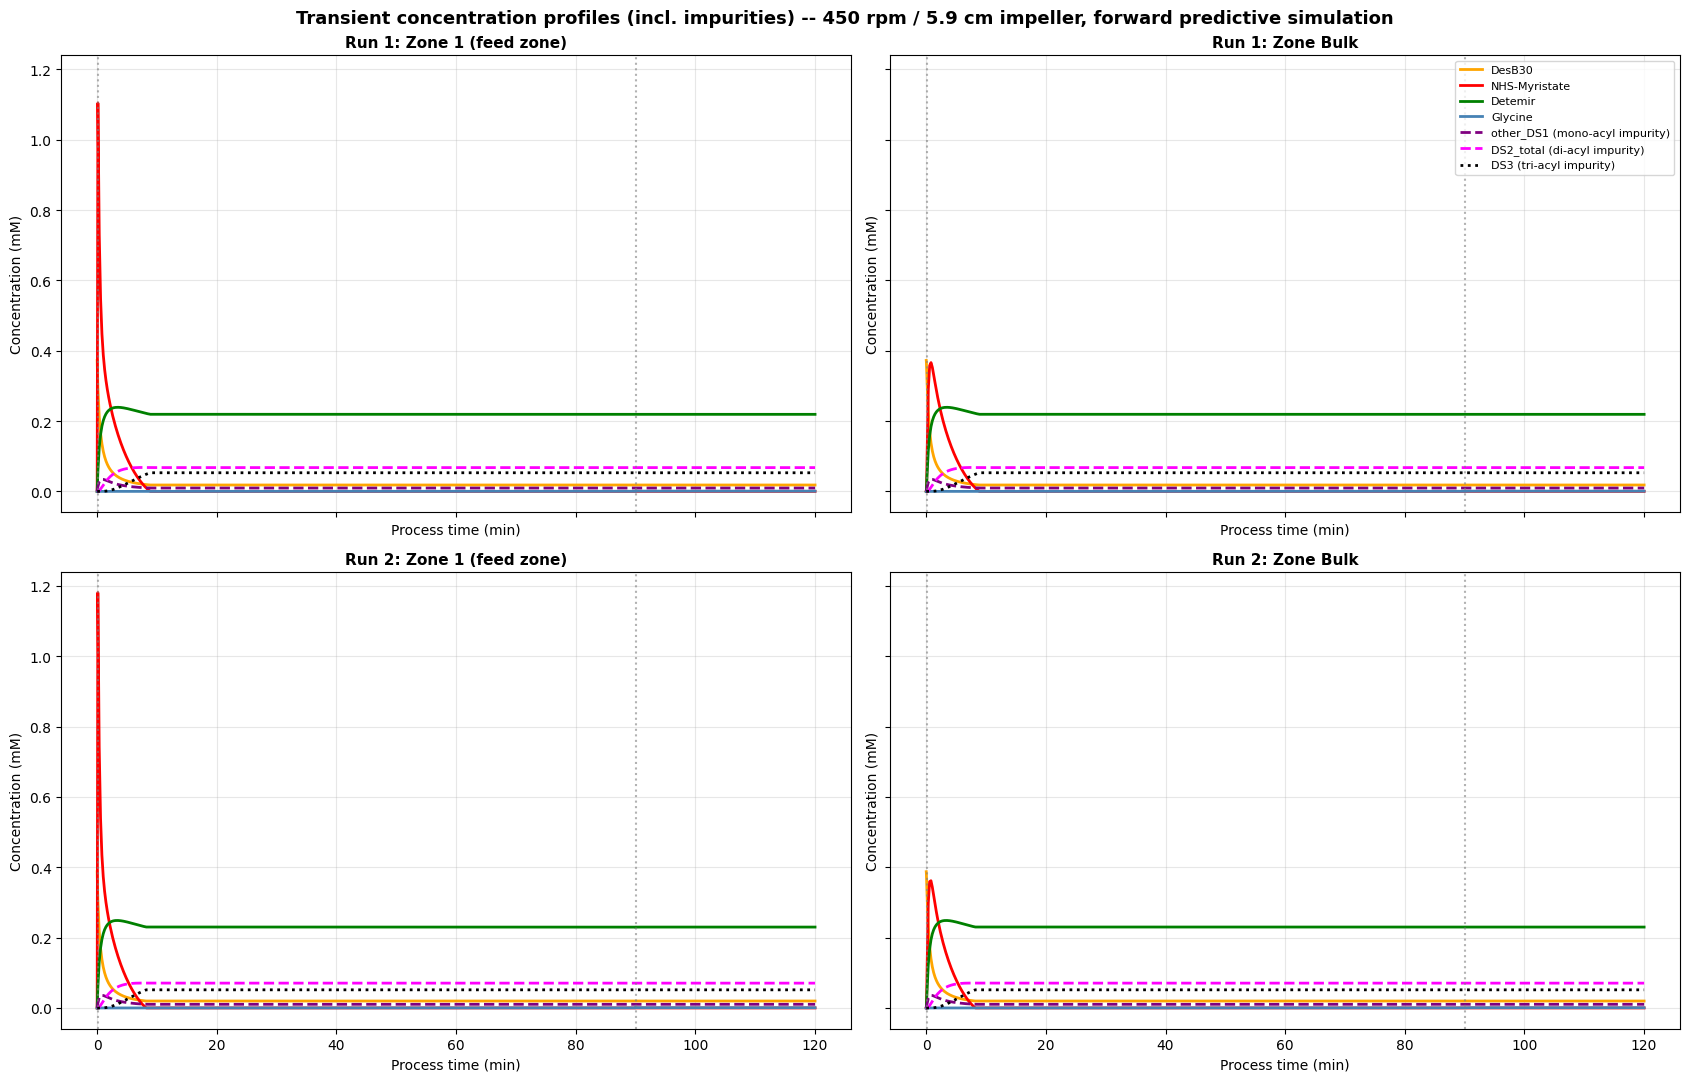

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(17, 11), sharex=True, sharey=True)
plot_species = ['desb30', 'nhs_myr', 'detemir', 'glycine', 'other_DS1', 'DS2_total', 'DS3']
plot_colors = {'desb30': 'orange', 'nhs_myr': 'red', 'detemir': 'green', 'glycine': 'steelblue',
               'other_DS1': 'purple', 'DS2_total': 'magenta', 'DS3': 'black'}
plot_styles = {'desb30': '-', 'nhs_myr': '-', 'detemir': '-', 'glycine': '-',
               'other_DS1': '--', 'DS2_total': '--', 'DS3': ':'}
plot_labels = {'desb30': 'DesB30', 'nhs_myr': 'NHS-Myristate', 'detemir': 'Detemir', 'glycine': 'Glycine',
               'other_DS1': 'other_DS1 (mono-acyl impurity)', 'DS2_total': 'DS2_total (di-acyl impurity)',
               'DS3': 'DS3 (tri-acyl impurity)'}
zone_data = {'Zone 1 (feed zone)': 'conc_zone1', 'Zone Bulk': 'conc_zone2'}

for row, (name, res) in enumerate(results.items()):
    for col, (zone_label, zone_key) in enumerate(zone_data.items()):
        ax = axes[row, col]
        for sp in plot_species:
            y = np.clip(res[zone_key][sp], 0.0, None) if sp == 'nhs_myr' else res[zone_key][sp]
            ax.plot(res['t_all_min'], y, label=plot_labels[sp], color=plot_colors[sp],
                     linestyle=plot_styles[sp], linewidth=2.0)
        for b in res['stage_boundaries_min'][:2]:
            ax.axvline(x=b, color='gray', linestyle=':', alpha=0.6)
        ax.set_title(f"{name}: {zone_label}", fontsize=11, fontweight='bold')
        ax.set_xlabel('Process time (min)')
        ax.set_ylabel('Concentration (mM)')
        ax.grid(True, alpha=0.3)
        if row == 0 and col == 1:
            ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Transient concentration profiles (incl. impurities) -- 450 rpm / 5.9 cm impeller, forward predictive simulation',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 9. Dual-compartment (axial zone) comparison
Zone 1 (feed zone) vs. Zone Bulk concentration for Detemir and NHS-Myr, both runs -- checks how close to
well-mixed the system is at these conditions. Because `Q` scales with rpm (Section 4), the 450 rpm circulation
flow here (&asymp;8.4 L/min) is roughly 2.8&times; the template's 160 rpm value, so the inter-zone gap is
expected to be smaller than in the template's validated 160 rpm case.

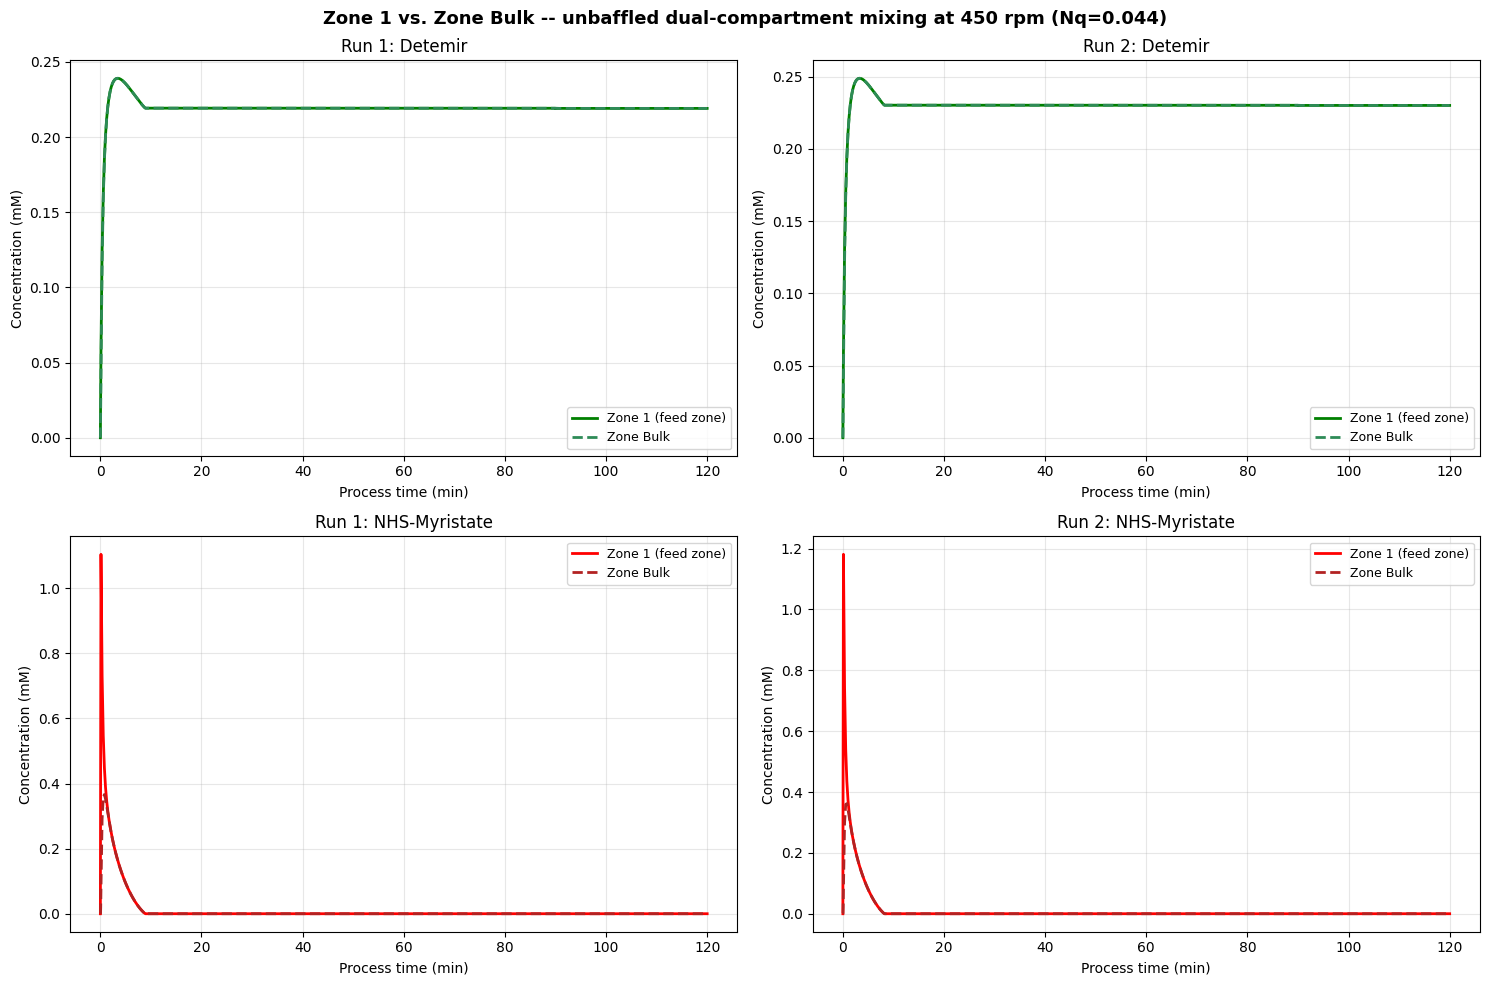

Run 1: max Zone1-vs-ZoneBulk gap -- Detemir: 0.0153 mM, NHS-Myr: 1.0232 mM
Run 2: max Zone1-vs-ZoneBulk gap -- Detemir: 0.0157 mM, NHS-Myr: 1.1005 mM


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for col, (name, res) in enumerate(results.items()):
    ax = axes[0, col]
    ax.plot(res['t_all_min'], res['conc_zone1']['detemir'], color='green', linewidth=2, label='Zone 1 (feed zone)')
    ax.plot(res['t_all_min'], res['conc_zone2']['detemir'], color='seagreen', linewidth=2, linestyle='--', label='Zone Bulk')
    ax.set_title(f'{name}: Detemir'); ax.set_xlabel('Process time (min)'); ax.set_ylabel('Concentration (mM)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax = axes[1, col]
    ax.plot(res['t_all_min'], np.clip(res['conc_zone1']['nhs_myr'], 0, None), color='red', linewidth=2, label='Zone 1 (feed zone)')
    ax.plot(res['t_all_min'], np.clip(res['conc_zone2']['nhs_myr'], 0, None), color='firebrick', linewidth=2, linestyle='--', label='Zone Bulk')
    ax.set_title(f'{name}: NHS-Myristate'); ax.set_xlabel('Process time (min)'); ax.set_ylabel('Concentration (mM)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle(f'Zone 1 vs. Zone Bulk -- unbaffled dual-compartment mixing at {N_RPM:.0f} rpm (Nq=0.044)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

for name, res in results.items():
    gap_det = np.max(np.abs(res['conc_zone1']['detemir'] - res['conc_zone2']['detemir']))
    gap_nhs = np.max(np.abs(np.clip(res['conc_zone1']['nhs_myr'], 0, None) - np.clip(res['conc_zone2']['nhs_myr'], 0, None)))
    print(f"{name}: max Zone1-vs-ZoneBulk gap -- Detemir: {gap_det:.4f} mM, NHS-Myr: {gap_nhs:.4f} mM")

## 10. Feed-duration and endpoint summary tables

In [15]:
print('FEED DURATION SUMMARY (Delta t = Volume / 440 mL/min)')
print('='*100)
print(f"{'Run':<8} {'NHS-Myr (mL)':>13} {'NHS-Myr Delta t (s)':>20} {'Glycine (mL)':>13} {'Glycine Delta t (s)':>20}")
for row in feed_summary_rows:
    print(f"{row['run']:<8} {row['V_nhs_mL']:13.1f} {row['T_feed_nhs_s']:20.3f} {row['V_gly_mL']:13.2f} {row['T_feed_gly_s']:20.3f}")

print()
print('ENDPOINT SUMMARY (purely predictive forward simulation, no optimization)')
print(f"Protocol: NHS-Myr feed -> {REACTION_HOLD_BEFORE_GLY_MIN:.0f} min hold -> Glycine feed -> "
      f"{POST_QUENCH_HOLD_MIN:.0f} min post-quench hold")
print('='*100)
print(f"{'Run':<8} {'Total protocol time (min)':>26} {'DesB30 conv. (%)':>17} {'Detemir yield (%)':>18} "
      f"{'Purity (%)':>11} {'Mass bal.':>10} {'NHS resid. (mmol)':>18} {'Gly resid. (mmol)':>18}")
for name, res in results.items():
    print(f"{name:<8} {res['total_time_s']/60:26.2f} {res['conversion_pct']:17.2f} {res['yield_pct']:18.2f} "
          f"{res['purity_pct']:11.2f} {res['mass_balance_ratio']:10.6f} {res['nhs_final_mmol']:18.6f} "
          f"{res['gly_final_mmol']:18.6f}")

FEED DURATION SUMMARY (Delta t = Volume / 440 mL/min)
Run       NHS-Myr (mL)  NHS-Myr Delta t (s)  Glycine (mL)  Glycine Delta t (s)
Run 1             53.7                7.323          2.97                0.405
Run 2             49.7                6.777          2.75                0.375

ENDPOINT SUMMARY (purely predictive forward simulation, no optimization)
Protocol: NHS-Myr feed -> 90 min hold -> Glycine feed -> 30 min post-quench hold
Run       Total protocol time (min)  DesB30 conv. (%)  Detemir yield (%)  Purity (%)  Mass bal.  NHS resid. (mmol)  Gly resid. (mmol)
Run 1                        120.01             95.06              59.63       62.73   1.000000           0.000297           0.002970
Run 2                        120.01             94.83              60.17       63.45   1.000000           0.000275           0.002750


## 11. Diagnostic observations (descriptive only -- no parameters were altered to produce these outcomes)

- **Vortex risk at 450 rpm.** The template deliberately capped its validated SOP at 160 rpm because that is
  the highest speed keeping this unbaffled vessel's impeller Froude number under the vortex-onset threshold
  (Fr_crit=0.15). At the task-specified 450 rpm, Fr_i is well above that threshold (Section 4) -- this
  operating point is predicted to be in a vortexing regime for an unbaffled tank. This is reported as-is per
  the "simulate what occurred" / zero-optimization mandate; the speed was not adjusted.
- **NHS-Myr is predicted to be numerically exhausted (<0.01% of its charge) roughly 9 minutes into the
  90-minute pre-Glycine hold** -- i.e. the model predicts the acylation/hydrolysis chemistry effectively stops
  about 81 minutes *before* Glycine is even added (Section 8 plots show DesB30, Detemir, and the impurity pool
  all plateauing well before the 90-minute mark). This is a direct consequence of the much higher 450 rpm
  circulation flow and the very short (few-second) NHS-Myr feed duration relative to the template's 160 rpm /
  minutes-long-feed SOP case, not of any change to the underlying kinetic rate constants.
- **Glycine dose is stoichiometrically negligible relative to NHS-Myr in both runs**, independent of the timeline
  correction. At 0.07507 mg/mL stock and the given pumped volumes, the glycine charge is roughly three orders of
  magnitude smaller (in moles) than the NHS-Myr charge -- far below the template's own 1.1x-molar-excess quench
  design target. Combined with the point above, Glycine arrives at 90 minutes to find essentially no NHS-Myr
  left to react with regardless of its own dose size -- so in this parameter regime, Glycine addition timing
  (immediately vs. after a 90-minute hold) does not change the predicted endpoint.
- **Mass balance** (total protein-pool moles at the endpoint vs. the initial DesB30 charge) is confirmed
  conserved to numerical precision in both runs (Section 10), consistent with the reaction network's
  moles-conserving structure.